In [17]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [18]:
df = pd.read_csv("train.csv")

In [19]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df = np.array(df)
np.random.shuffle(df)
df.shape


(42000, 785)

In [21]:
df_train = df[0:33600].T
df_test = df[33600:].T

X_train = df_train[1:]
X_test = df_test[1:]

y_train = df_train[0]
y_test = df_test[0]


In [22]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_deriv(z):
    return z > 0

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

In [23]:
def init_parameters():
    w1 = np.random.randn(10, 784)
    b1 = np.random.randn(10, 1)

    w2 = np.random.randn(10, 10)
    b2 = np.random.randn(10, 1)

    return w1, b1, w2, b2

In [24]:
def forward_prop(w1, b1, w2, b2, X):
    z1 = w1 @ X + b1
    a1 = relu(z1)

    z2 = w2 @ a1 + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2

In [25]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    
    return one_hot_Y.T

In [26]:

def back_propagation(z1, z2, a1, a2, w1, w2, X, Y):
    one_hot_Y = one_hot(Y)

    dZ2 = a2 - one_hot_Y
    dW2 = 1 / Y.size * dZ2.dot(a1.T)
    db2 = 1 / Y.size * np.sum(dZ2)
    dZ1 = w2.T @ (dZ2) * relu_deriv(z1)
    dW1 = 1 / Y.size * dZ1.dot(X.T)
    db1 = 1 / Y.size * np.sum(dZ1)
    return dW1, db1, dW2, db2

In [27]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [28]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_parameters()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_propagation(Z1, Z2, A1, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [29]:
W1, b1, W2, b2 = gradient_descent(X_train, y_train, 0.10, 500)

C:\Users\laksh\AppData\Local\Temp\ipykernel_26200\509780185.py:14: RuntimeWarning: overflow encountered in exp
  return np.exp(x) / np.sum(np.exp(x))
C:\Users\laksh\AppData\Local\Temp\ipykernel_26200\509780185.py:14: RuntimeWarning: invalid value encountered in divide
  return np.exp(x) / np.sum(np.exp(x))


Iteration:  0
[5 2 7 ... 5 5 3] [8 2 7 ... 6 6 9]
0.19979166666666667
Iteration:  10
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  20
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  30
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  40
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  50
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  60
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  70
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  80
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  90
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  100
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  110
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  120
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Iteration:  130
[0 0 0 ... 0 0 0] [8 2 7 ... 6 6 9]
0.09770833333333333
Ite

In [30]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [0]
Label:  8


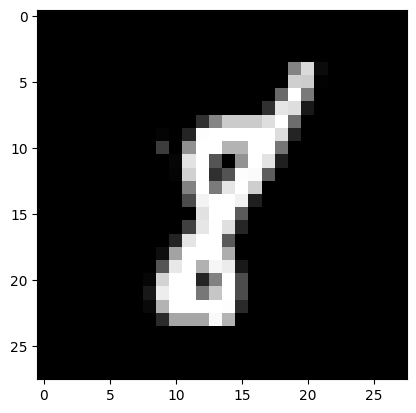

Prediction:  [0]
Label:  2


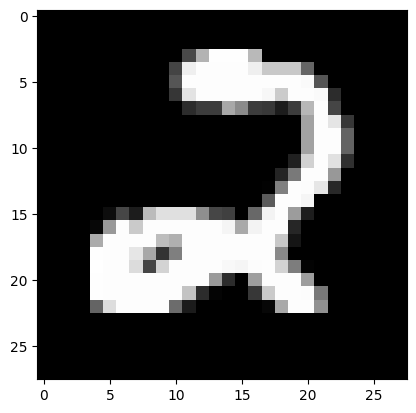

Prediction:  [0]
Label:  7


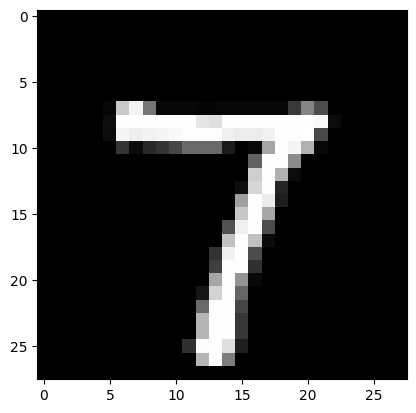

Prediction:  [0]
Label:  4


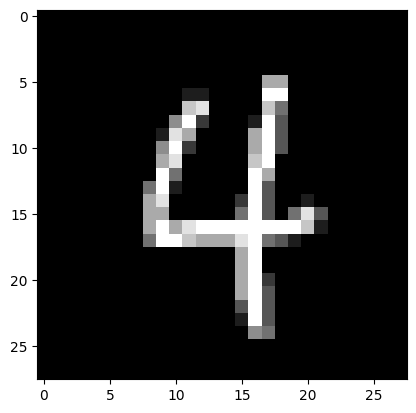

In [31]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [32]:
dev_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(dev_predictions, y_test)

[0 0 0 ... 0 0 0] [5 0 5 ... 7 2 3]


0.10107142857142858